This ipynb file is made to add perturbations (noise) to the selected .wav files (with already Wiener filter)

In [9]:
# Standard libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil


from scipy.io import wavfile
from scipy.signal import wiener

# load data
DATA_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME"
WIENER_INPUT_DIR = os.path.join(DATA_PATH, "wiener_filtered_audio")
PINK_NOISE_OUTPUT_DIR = os.path.join(DATA_PATH, "wiener_pink_noise_perturbations")

os.makedirs(PINK_NOISE_OUTPUT_DIR, exist_ok=True)

In [10]:
# Collect WAV files
wiener_audio_files = []

for root, dirs, files in os.walk(WIENER_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            wiener_audio_files.append(os.path.join(root, file))

print(f"Number of Wiener-filtered audio files: {len(wiener_audio_files)}")

Number of Wiener-filtered audio files: 1941


In [11]:
def load_wav_file(file_path):
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    signal = np.clip(signal, -32768, 32767)
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)

def generate_pink_noise(N):
    """
    Generate pink noise using frequency domain filtering (1/f).
    """
    # White noise in frequency domain
    X = np.random.randn(N)
    X_fft = np.fft.rfft(X)

    # Frequencies
    freqs = np.fft.rfftfreq(N)

    # Avoid division by zero
    freqs[0] = freqs[1]

    # Apply 1/sqrt(f) filter → pink noise
    X_fft = X_fft / np.sqrt(freqs)

    # Back to time domain
    pink = np.fft.irfft(X_fft, n=N)

    return pink

def add_pink_noise(signal, noise_std_fraction):
    signal = signal.astype(np.float32)

    signal_std = np.std(signal)

    # Generate pink noise
    pink_noise = generate_pink_noise(len(signal))

    # Normalize pink noise
    pink_noise = pink_noise / np.std(pink_noise)

    # Scale to desired level
    noise_std = noise_std_fraction * signal_std
    pink_noise = pink_noise * noise_std

    noisy_signal = signal + pink_noise
    return noisy_signal

def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [12]:
perturbations = {
    "low_pink_noise": 0.005,
    "medium_pink_noise": 0.02,
    "high_pink_noise": 0.05,
    "very_high_pink_noise": 0.1
}

In [13]:
processed_rows = []

for input_path in wiener_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, noise_std_fraction in perturbations.items():
            noisy_signal = add_pink_noise(signal, noise_std_fraction)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=WIENER_INPUT_DIR,
                output_root=PINK_NOISE_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, noisy_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_wiener_file_path": input_path,
                "perturbation": perturbation_name,
                "noise_std_fraction": noise_std_fraction,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print("Finished processing Pink noise perturbations.")

Finished processing Pink noise perturbations.


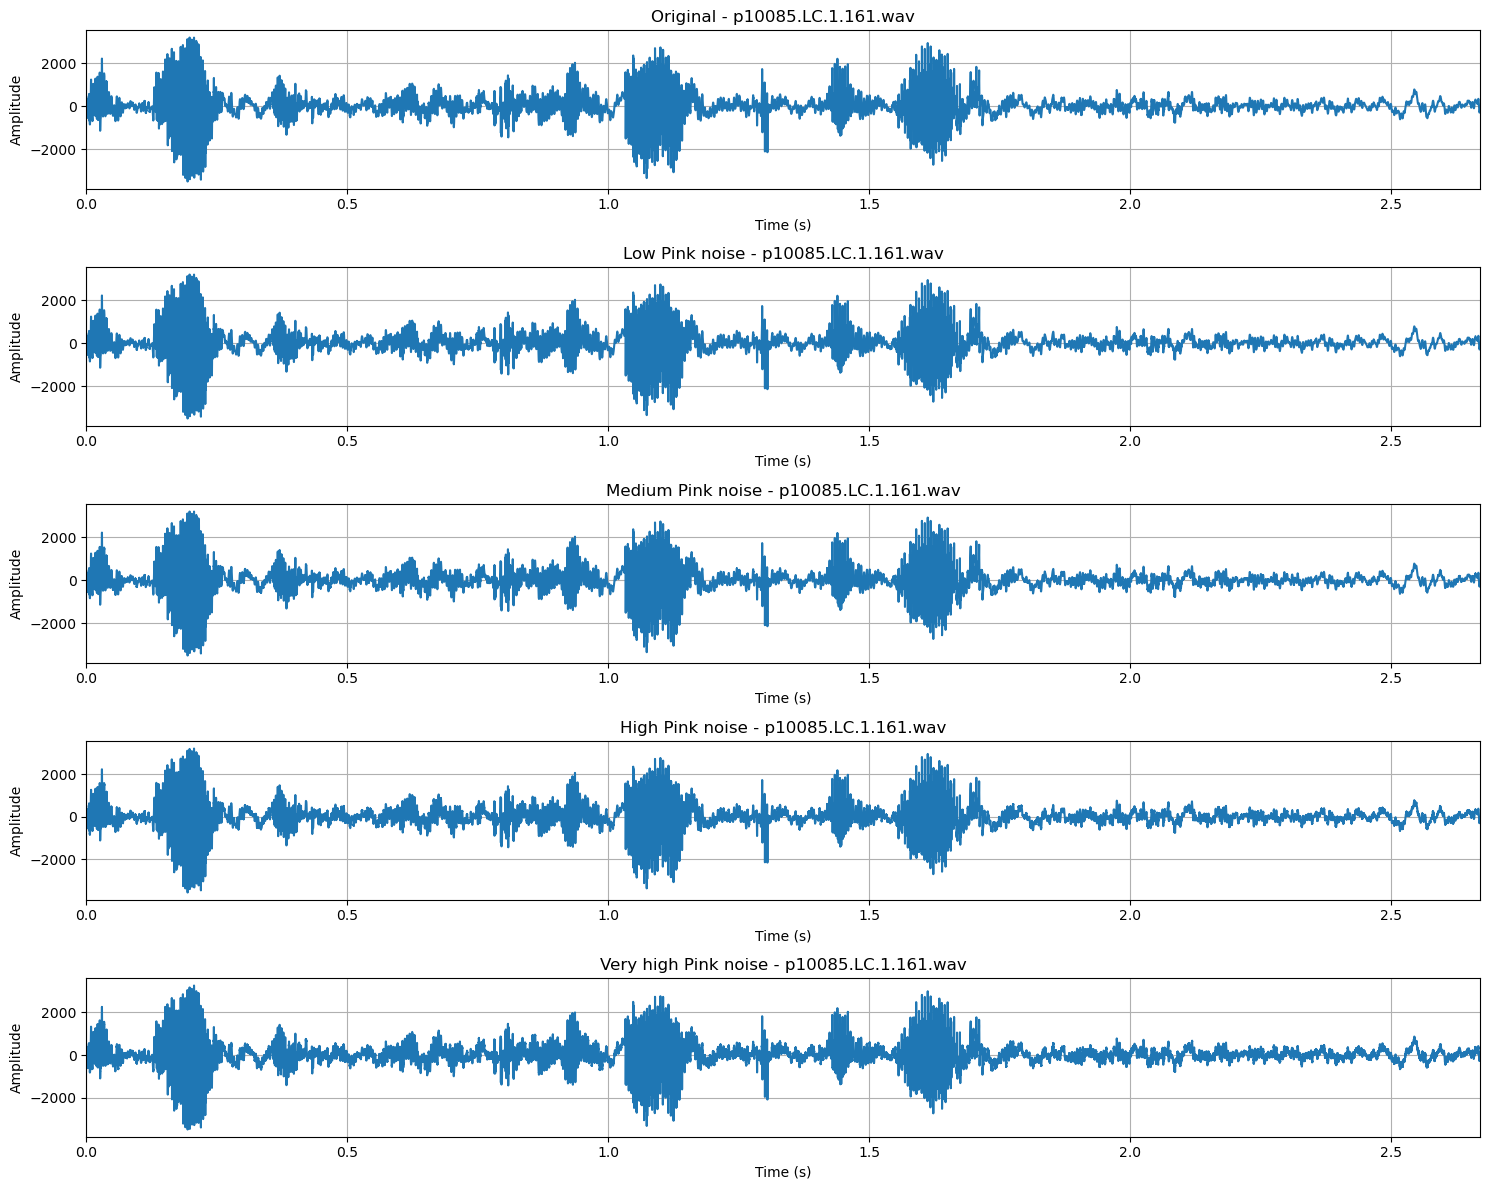

In [14]:
# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "Original": original_file,
    "Low Pink noise": os.path.join(PINK_NOISE_OUTPUT_DIR, "low_pink_noise", participant_id, filename),
    "Medium Pink noise": os.path.join(PINK_NOISE_OUTPUT_DIR, "medium_pink_noise", participant_id, filename),
    "High Pink noise": os.path.join(PINK_NOISE_OUTPUT_DIR, "high_pink_noise", participant_id, filename),
    "Very high Pink noise": os.path.join(PINK_NOISE_OUTPUT_DIR, "very_high_pink_noise", participant_id, filename),
}

# Plot
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(perturbed_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"{label} - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))  # first 3 seconds
    plt.grid(True)

plt.tight_layout()
plt.show()

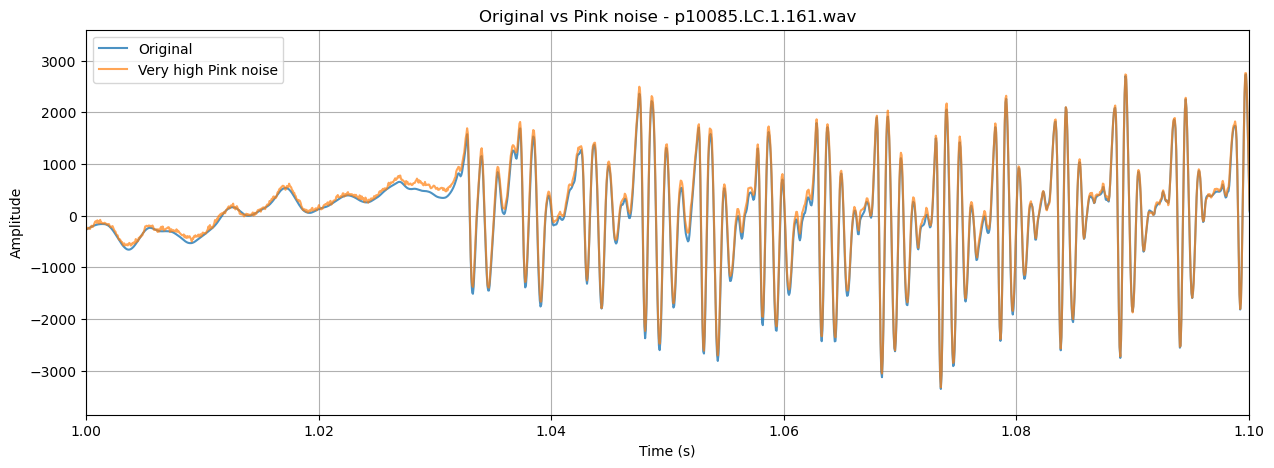

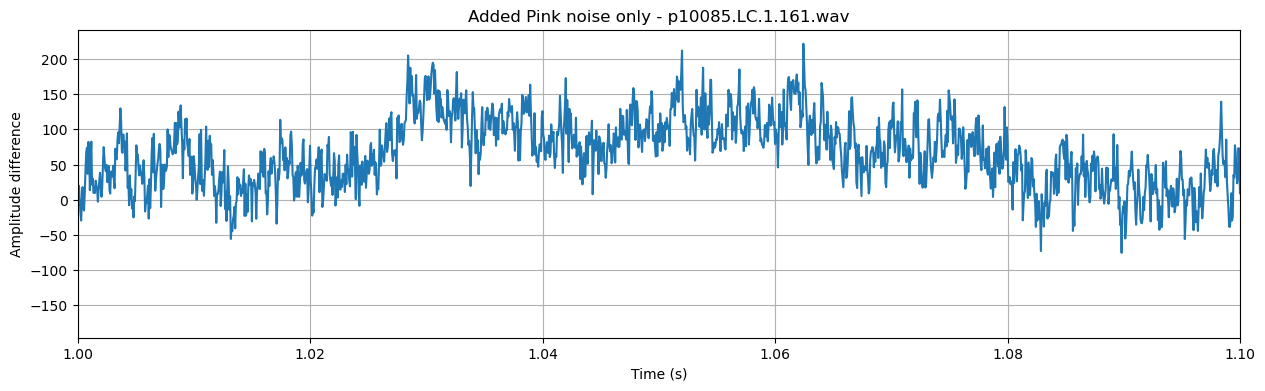

In [15]:
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)
noisy_file = os.path.join(PINK_NOISE_OUTPUT_DIR, "very_high_pink_noise", participant_id, filename)

sr_orig, signal_orig = load_wav_file(original_file)
sr_noisy, signal_noisy = load_wav_file(noisy_file)

signal_orig = signal_orig.astype(np.float32)
signal_noisy = signal_noisy.astype(np.float32)

time = np.arange(len(signal_orig)) / sr_orig

# 🔹 Plot original vs pink noise
plt.figure(figsize=(15, 5))
plt.plot(time, signal_orig, label="Original", alpha=0.8)
plt.plot(time, signal_noisy, label="Very high Pink noise", alpha=0.7)
plt.xlim(1.0, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Original vs Pink noise - {filename}")
plt.legend()
plt.grid(True)
plt.show()

difference = signal_noisy - signal_orig

plt.figure(figsize=(15, 4))
plt.plot(time, difference)
plt.xlim(1.0, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude difference")
plt.title(f"Added Pink noise only - {filename}")
plt.grid(True)
plt.show()